In [70]:
dnd5rulebooklink = "https://ordempendragon.wordpress.com/wp-content/uploads/2017/04/dd-5e-livro-do-jogador-fundo-branco-biblioteca-c3a9lfica.pdf"

import requests

# Link do PDF e caminho local para salvar
pdf_url = "https://ordempendragon.wordpress.com/wp-content/uploads/2017/04/dd-5e-livro-do-jogador-fundo-branco-biblioteca-c3a9lfica.pdf"
pdf_path = "dd5e_livro_jogador.pdf"
output_md_path = "spells_dnd5e.md"

# Baixar o PDF
response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)


In [128]:
from PyPDF2 import PdfReader

# Caminhos
pdf_path = "dd5e_livro_jogador.pdf"
output_md_path = "spells_dnd5e.md"
output_json_path = "spells_dnd5e.json"

# Ler o PDF
reader = PdfReader(pdf_path)

# Extrair o texto cru
extracted_text = ""
spells_pages = []

start_page = 212
end_page = 288

# using this range
# notes para o markdown as paginas com magias estao no intervalo 213-288 de paginas por isso foi necessario usar esse range
for i in range(start_page, end_page):  # 213-288 inclusive
    page = reader.pages[i]
    text = page.extract_text()
    if text:
        text = text.strip()
        extracted_text += text + "\n\n"

with open(output_md_path, "w", encoding="utf-8") as f:
    f.write(extracted_text)

print("Arquivos salvos sem formatação extra.")


Arquivos salvos sem formatação extra.


In [129]:
import re

with open("spells_dnd5e.md", "r", encoding="utf-8") as f:
    lines = f.readlines()

new_lines = []
for i in range(len(lines) - 1):
    line = lines[i].rstrip()
    next_line = lines[i + 1].lower()

    # Verifica se a próxima linha parece indicar início da magia
    if "° nível de" in next_line or "truque de" in next_line:
        # Divide a linha atual em: [parte antes do nome] [nome da magia]
        match = re.search(r"^(.*?[\.\!\?])\s*([A-ZÇÃÕÉÊÍÓÚÀÜ]{2,}(?:\s+[A-ZÇÃÕÉÊÍÓÚÀÜ]{2,})*)\s*$", line)
        if match:
            before = match.group(1).strip()
            title = match.group(2).strip()
            new_lines.append(before + "\n")
            new_lines.append(title + "\n")
            continue

    new_lines.append(line + "\n")

# Adiciona a última linha se faltou
if len(lines) > 0:
    new_lines.append(lines[-1])

with open("spells_dnd5e_titulos_corrigidos.md", "w", encoding="utf-8") as f:
    f.writelines(new_lines)

print("Quebra aplicada: nomes de magia extraídos de linhas coladas.")


Quebra aplicada: nomes de magia extraídos de linhas coladas.


In [130]:
import re

# Carrega o texto original
with open("spells_dnd5e_titulos_corrigidos.md", "r", encoding="utf-8") as f:
    lines = f.readlines()

spells_array = []
start_idx = None

# Função que detecta se a linha parece ser um título em maiúsculas
def is_upper_title(line):
    line = line.strip()
    return (
        line.isupper()
        and len(line) > 3
        and not line.isnumeric()
    )

for i in range(1, len(lines)):
    # Detecta início de magia: linha em caps seguida por "nível de" ou "Truque de"
    if is_upper_title(lines[i - 1]) and (
        "° nível de" in lines[i].lower() or "Truque de" in lines[i]
    ):
        if start_idx is not None:
            spells_array.append("".join(lines[start_idx:i - 1]).strip())
        start_idx = i - 1  # começa na linha do nome da magia

# Adiciona o último bloco
if start_idx is not None:
    spells_array.append("".join(lines[start_idx:]).strip())

# Salva com separadores
with open("spells_dnd5e_separado.md", "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(spells_array))

print(f"{len(spells_array)} magias separadas com '---' e salvas em spells_dnd5e_separado.md")





356 magias separadas com '---' e salvas em spells_dnd5e_separado.md


In [134]:
import re

# o texto de contagem de páginas eh bem inutil da silva, preciso remover as ocorrências dele à força

start_page = 212
end_page = 288

# Carregar o texto original
with open("spells_dnd5e_separado.md", "r", encoding="utf-8") as f:
    text = f.read()

# Lista para armazenar ocorrências encontradas
found_occurrences = []

# Regex que pega ocorrências de números de página em qualquer posição, mas isoladas por limites de palavra ou pontuação
for page_num in range(start_page, end_page + 1):
    # Procura o número entre espaços, pontuação ou quebras de linha
    matches = re.findall(rf"(?<!\d)\b{page_num}\b(?!\d)", text)
    if matches:
        found_occurrences.extend([str(page_num)] * len(matches))

# Exibir o que foi encontrado
print(f"{len(found_occurrences)} ocorrências de números de página entre {start_page} e {end_page} detectadas.")
print("Exemplos únicos encontrados:", sorted(set(found_occurrences)))

# Substituir essas ocorrências por string vazia
for page_num in range(start_page, end_page + 1):
    text = re.sub(rf"(?<!\d)\b{page_num}\b(?!\d)", "", text)

# Agora processa os blocos de magia
blocks = text.split("\n\n---\n\n")
cleaned_blocks = []

for block in blocks:
    lines = block.strip().splitlines()
    if len(lines) < 3:
        continue

    # Adiciona vírgulas ao fim das linhas de atributos
    for i in range(2, len(lines)):
        if re.match(r"^(Tempo de Conjuração|Alcance|Componentes|Duração)\s*:", lines[i]):
            lines[i] = lines[i].rstrip() + ","

    cleaned_block = "\n".join(lines).strip()
    cleaned_blocks.append(cleaned_block)

# Salva o texto limpo com blocos separados por ---
with open("spells_dnd5e_limpo.md", "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(cleaned_blocks))

print("Texto limpo salvo em spells_dnd5e_limpo.md")



79 ocorrências de números de página entre 212 e 288 detectadas.
Exemplos únicos encontrados: ['216', '217', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '246', '247', '248', '249', '250', '251', '252', '253', '254', '255', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '267', '268', '269', '270', '271', '272', '273', '274', '275', '276', '277', '278', '279', '280', '281', '282', '283', '284', '285', '286', '287', '288']
Texto limpo salvo em spells_dnd5e_limpo.md


In [135]:
import re
import csv
# TODO (s4hlo) separar atributos dos textos em novas colunas
# Lê o texto onde cada feitiço está separado por '---'
with open("spells_dnd5e_limpo.md", "r", encoding="utf-8") as f:
    raw = f.read()

# Divide os feitiços pelo separador
blocks = raw.split("\n\n---\n\n")

data = []

for block in blocks:
    lines = block.strip().splitlines()
    if len(lines) < 2:
        continue

    nome = lines[0].strip()

    # Detecta o nível e o tipo
    nivel_linha = lines[1].strip()
    nivel = 0
    tipo = "indefinido"

    if "Truque de" in nivel_linha:
        nivel = 0
        tipo = nivel_linha.lower().replace("Truque de", "").replace("(ritual)", "").strip()
    else:
        match = re.match(r"(\d+)°\s+nível\s+de\s+(.+)", nivel_linha.lower())
        if match:
            nivel = int(match.group(1))
            tipo = match.group(2).replace("(ritual)", "").strip()

    # O restante é o texto da magia
    texto = "\n".join(lines[2:]).strip()

    data.append({
        "nome": nome,
        "nivel": nivel,
        "tipo": tipo,
        "texto": texto
    })

# Escreve em CSV
with open("spells.csv", "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["nome", "nivel", "tipo", "texto"])
    writer.writeheader()
    writer.writerows(data)

print(f"{len(data)} magias exportadas para spells.csv com sucesso.")


356 magias exportadas para spells.csv com sucesso.


RAFAEL MAGNO FREITAS NUNES

In [136]:

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

df = pd.read_csv("spells.csv")
print(f"Loaded {len(df)} spells")
print("\nFirst few rows:")
print(df.head())


Loaded 356 spells

First few rows:
               nome  nivel          tipo  \
0  ACALMAR E MOÇÕES      2  encantamento   
1       ADIVINHAÇÃO      4   adivinhação   
2             AJUDA      2     abjuração   
3            ALARME      1     abjuração   
4     ALIADO PLANAR      6    conjuração   

                                               texto  
0  Tempo de Conjuração: 1 ação,\nAlcance : 18 met...  
1  Tempo de Conjuração : 1 ação,\nAlcance : Pesso...  
2  Tempo de Conjuração: 1 ação,\nAlcance : 9 metr...  
3  Tempo de Conjuração: 1 minuto,\nAlcance : 9 me...  
4  Tempo de Conjuração: 10 minutos,\nAlcance : 18...  


In [153]:
def make_lowercase(text: str) -> str:
    return text.lower()

def remove_excessive_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def remove_break_lines(text: str) -> str:
    return re.sub(r"\n", " ", text).strip()

def remove_whitespace_before_punctuation(text: str) -> str:
    return re.sub(r"\s+([.,!?:])", r"\1", text).strip()

pipeline_clean_text = Pipeline(
    steps=[
        ("make_lowercase", FunctionTransformer(lambda x: [make_lowercase(i) for i in x], validate=False)),
        ("remove_excessive_whitespace", FunctionTransformer(lambda x: [remove_excessive_whitespace(i) for i in x], validate=False)),
        ("remove_break_lines", FunctionTransformer(lambda x: [remove_break_lines(i) for i in x], validate=False)),
        ("remove_whitespace_before_punctuation", FunctionTransformer(lambda x: [remove_whitespace_before_punctuation(i) for i in x], validate=False)),
    ]
)

def safe_clean_text(x):
    try:
        return pipeline_clean_text.transform([str(x)])[0]
    except Exception:
        return x

df["texto"] = df["texto"].apply(safe_clean_text)

print("First 5 cleaned texts:")
for i in range(min(5, len(df))):
    print(f"\nText {i + 1}:")
    print(f"Content: {df['texto'].iloc[i]}")



First 5 cleaned texts:

Text 1:
Content: tempo de conjuração: 1 ação, alcance: 18 metros, componentes: v, s, duração: concentração, até 1 minuto, você tenta suprimir emoções fortes em um grupo de pessoas. cada humanoide em uma esfera de 6 metros de raio, centrada em um ponto que você escolher dentro do alcance, deve realizar um teste de resistência de carisma; uma criatura pode escolher falhar nesse teste, se desejar. se uma criatura falhar na resistência, escolha um dentre os dois efeitos a seguir. você pode suprimir qualquer efeito que esteja deixando a criatura enfeitiçada ou amedrontada. quando essa magia terminar, qualquer efeito suprimido volta a funcionar, considerando que sua duração não tenha acabado nesse meio tempo. alternativamente, você pode tornar um alvo indiferente às criaturas que você escolher que forem hostis a ele. essa indiferença acaba se o alvo for atacado ou ferido por uma magia ou se ele testemunhar qualquer dos seus amigos sendo ferido. quando a magia terminar

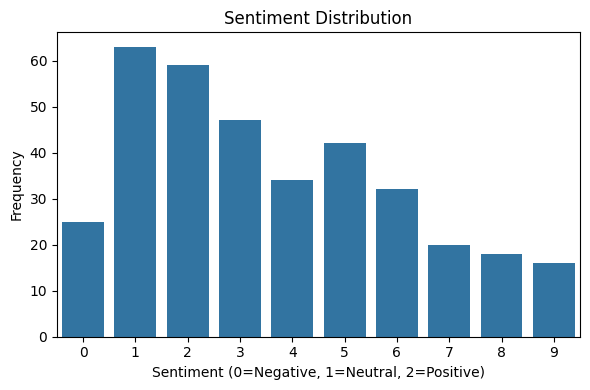

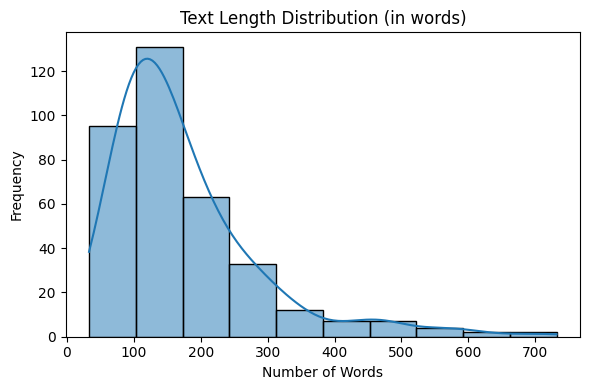

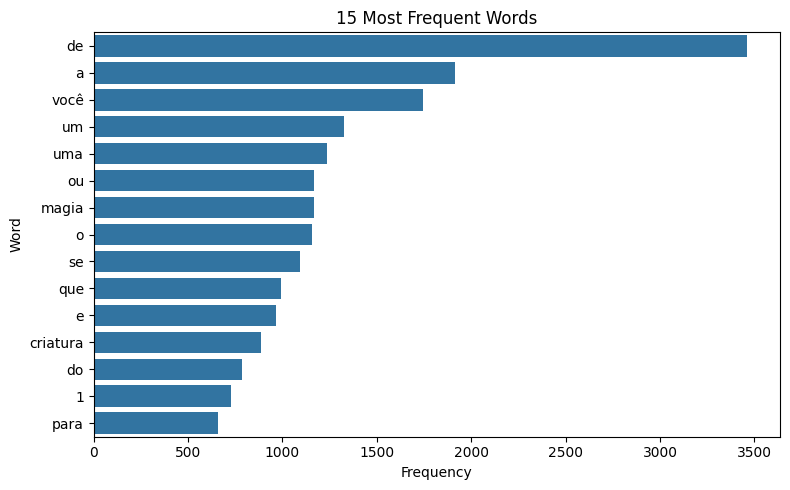

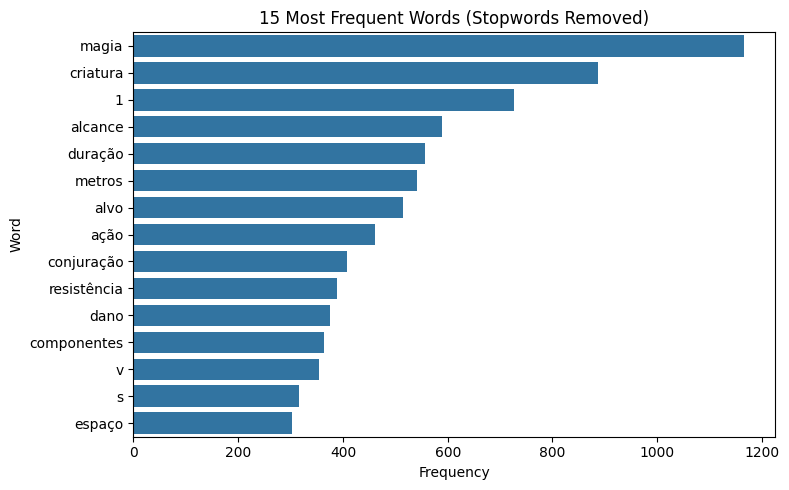

In [ ]:


# TODO (s4hlo) check more relevant metrics
# TODO (s4hlo) show metrics for tf idf maybe can be useful

# Plot sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='nivel')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Negative, 1=Neutral, 2=Positive)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Calculate and plot text length distribution
df["text_length"] = df["texto"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6, 4))
sns.histplot(df["text_length"], bins=10, kde=True)
plt.title("Text Length Distribution (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Tokenize and plot word frequency
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

all_words = [word for text in df["texto"] for word in tokenize(text)]
word_freq = Counter(all_words).most_common(15)
words, freqs = zip(*word_freq)

plt.figure(figsize=(8, 5))
sns.barplot(x=list(freqs), y=list(words))
plt.title("15 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

# Remove stopwords and plot word frequency
from spacy.lang.pt.stop_words import STOP_WORDS

def remove_stopwords(text):
    return [word for word in tokenize(text) if word not in STOP_WORDS]

all_words_no_stop = [word for text in df["texto"] for word in remove_stopwords(text)]
word_freq_no_stop = Counter(all_words_no_stop).most_common(15)
words_no_stop, freqs_no_stop = zip(*word_freq_no_stop)

plt.figure(figsize=(8, 5))
sns.barplot(x=list(freqs_no_stop), y=list(words_no_stop))
plt.title("15 Most Frequent Words (Stopwords Removed)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


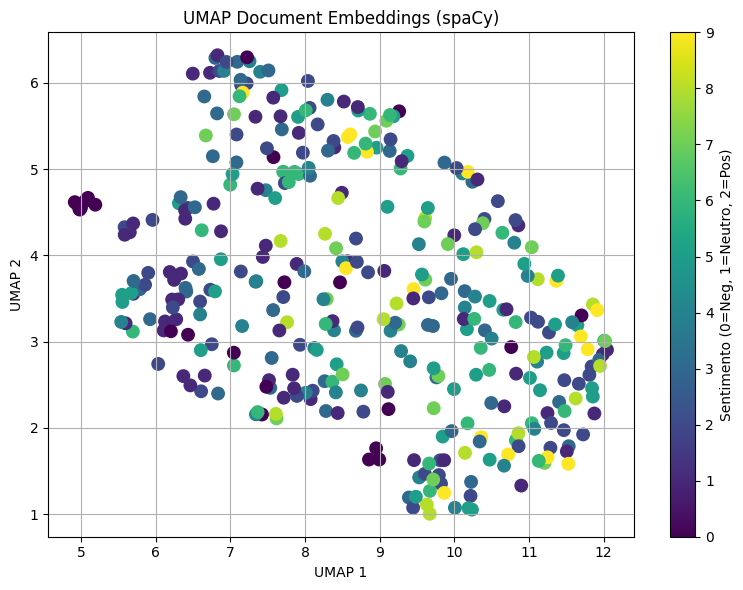

In [158]:
import spacy
import numpy as np
import umap

nlp = spacy.load("pt_core_news_md")

df["embedding"] = df["texto"].apply(lambda x: nlp(x).vector)

X = np.vstack(df["embedding"].values)
y = df["nivel"].values

X_umap = umap.UMAP(random_state=42).fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y,  s=80)
plt.title("UMAP Document Embeddings (spaCy)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Sentimento (0=Neg, 1=Neutro, 2=Pos)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [161]:
import plotly.express as px
import pandas as pd
import spacy
import numpy as np
import umap
import textwrap

# Embedding com spaCy
nlp = spacy.load("pt_core_news_md")
df["embedding"] = df["texto"].apply(lambda x: nlp(x).vector)
X = np.vstack(df["embedding"].values)

# UMAP
X_umap = umap.UMAP(random_state=42).fit_transform(X)

# Adiciona coordenadas ao DataFrame
df["umap_x"] = X_umap[:, 0]
df["umap_y"] = X_umap[:, 1]

# Formata o texto para hover com quebras de linha
df["texto_hover"] = df["texto"].apply(lambda t: "<br>".join(textwrap.wrap(t, width=80)))

# Gráfico interativo com Plotly
fig = px.scatter(
    df,
    x="umap_x",
    y="umap_y",
    color="tipo",  # ou "tipo"
    hover_name="nome",
    hover_data={
        "nivel": True,
        "tipo": True,
        "texto_hover": True,
        "texto": False,
        "umap_x": False,
        "umap_y": False
    },
    title="Embeddings de Magias (UMAP + spaCy)",
    labels={"nivel": "Nível da magia"},
    width=900,
    height=700
)

fig.show()


/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



pos coleta de dados - tratamento